<a href="https://colab.research.google.com/github/DAGGUPATIKASI/Plant-Disease-Detection/blob/main/Plant_Disease_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ── Step 1: Clone the official PlantVillage GitHub repo ──────────────────────
!git clone https://github.com/spMohanty/PlantVillage-Dataset.git

# ── Step 2: Check what's inside ───────────────────────────────────────────────
import os

base_path = '/content/PlantVillage-Dataset/raw/color'
classes   = sorted(os.listdir(base_path))

print(f"Total classes : {len(classes)}")
print(f"\nClass names:")
for i, c in enumerate(classes):
    count = len(os.listdir(os.path.join(base_path, c)))
    print(f"  {i+1:2}. {c:45s} → {count} images")

Cloning into 'PlantVillage-Dataset'...
remote: Enumerating objects: 163264, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 163264 (delta 16), reused 25 (delta 9), pack-reused 163229 (from 1)
Receiving objects: 100% (163264/163264), 2.00 GiB | 24.46 MiB/s, done.
Resolving deltas: 100% (115/115), done.
Updating files: 100% (182404/182404), done.
Total classes : 38

Class names:
   1. Apple___Apple_scab                            → 630 images
   2. Apple___Black_rot                             → 621 images
   3. Apple___Cedar_apple_rust                      → 275 images
   4. Apple___healthy                               → 1645 images
   5. Blueberry___healthy                           → 1502 images
   6. Cherry_(including_sour)___Powdery_mildew      → 1052 images
   7. Cherry_(including_sour)___healthy             → 854 images
   8. Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot → 513 images
   9. Corn_(maize)___Comm

In [ ]:
# ── Download 300 MB zip directly ──────────────────────────────────────────────
!wget -q --show-progress \
  "https://data.mendeley.com/public-files/datasets/tywbtsjrjv/files/d5652a28-c1d8-4b76-97f3-72fb80f94efc/file_downloaded" \
  -O /content/plantvillage.zip

# ── Extract ────────────────────────────────────────────────────────────────────
!unzip -q /content/plantvillage.zip -d /content/plant_data
!ls /content/plant_data

/content/plantvilla 100%[===================>] 827.82M  19.7MB/s    in 44s     
Plant_leave_diseases_dataset_without_augmentation


In [ ]:
# ── Install ────────────────────────────────────────────────────────────────────
!pip install -q tensorflow-datasets

import tensorflow_datasets as tfds
import tensorflow as tf
import numpy as np
import os

# ── Download automatically (~300 MB, takes 2–3 minutes) ───────────────────────
(train_ds, val_ds, test_ds), info = tfds.load(
    'plant_village',
    split=['train[:70%]', 'train[70%:85%]', 'train[85%:]'],
    with_info=True,
    as_supervised=True
)

CLASS_NAMES  = info.features['label'].names
NUM_CLASSES  = info.features['label'].num_classes
TOTAL_IMAGES = info.splits['train'].num_examples

print(f"Total images  : {TOTAL_IMAGES:,}")
print(f"Total classes : {NUM_CLASSES}")
print(f"Train size    : {int(TOTAL_IMAGES * 0.70):,}")
print(f"Val size      : {int(TOTAL_IMAGES * 0.15):,}")
print(f"Test size     : {int(TOTAL_IMAGES * 0.15):,}")
print(f"\nClass names (first 10):")
for i, name in enumerate(CLASS_NAMES[:10]):
    print(f"  {i+1}. {name}")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/plant_village/incomplete.E2ZTIU_1.0.2/plant_village-train.tfrecord*...:   …

Dataset plant_village downloaded and prepared to /root/tensorflow_datasets/plant_village/1.0.2. Subsequent calls will reuse this data.
Total images  : 54,303
Total classes : 38
Train size    : 38,012
Val size      : 8,145
Test size     : 8,145

Class names (first 10):
  1. Apple___Apple_scab
  2. Apple___Black_rot
  3. Apple___Cedar_apple_rust
  4. Apple___healthy
  5. Blueberry___healthy
  6. Cherry___healthy
  7. Cherry___Powdery_mildew
  8. Corn___Cercospora_leaf_spot Gray_leaf_spot
  9. Corn___Common_rust
  10. Corn___healthy


In [ ]:
 # ── Preprocess & batch (plug directly into your training code) ────────────────
IMG_SIZE   = (160, 160)
BATCH_SIZE = 64
AUTOTUNE   = tf.data.AUTOTUNE

def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, 0.2)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    image = tf.image.random_saturation(image, 0.8, 1.2)
    return image, label

train_dataset = (
    train_ds
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .map(augment,    num_parallel_calls=AUTOTUNE)
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_dataset = (
    val_ds
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_dataset = (
    test_ds
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("Datasets ready!")
print(f"Train batches : {len(train_dataset)}")
print(f"Val batches   : {len(val_dataset)}")
print(f"Test batches  : {len(test_dataset)}")

Datasets ready!
Train batches : 594
Val batches   : 128
Test batches  : 128


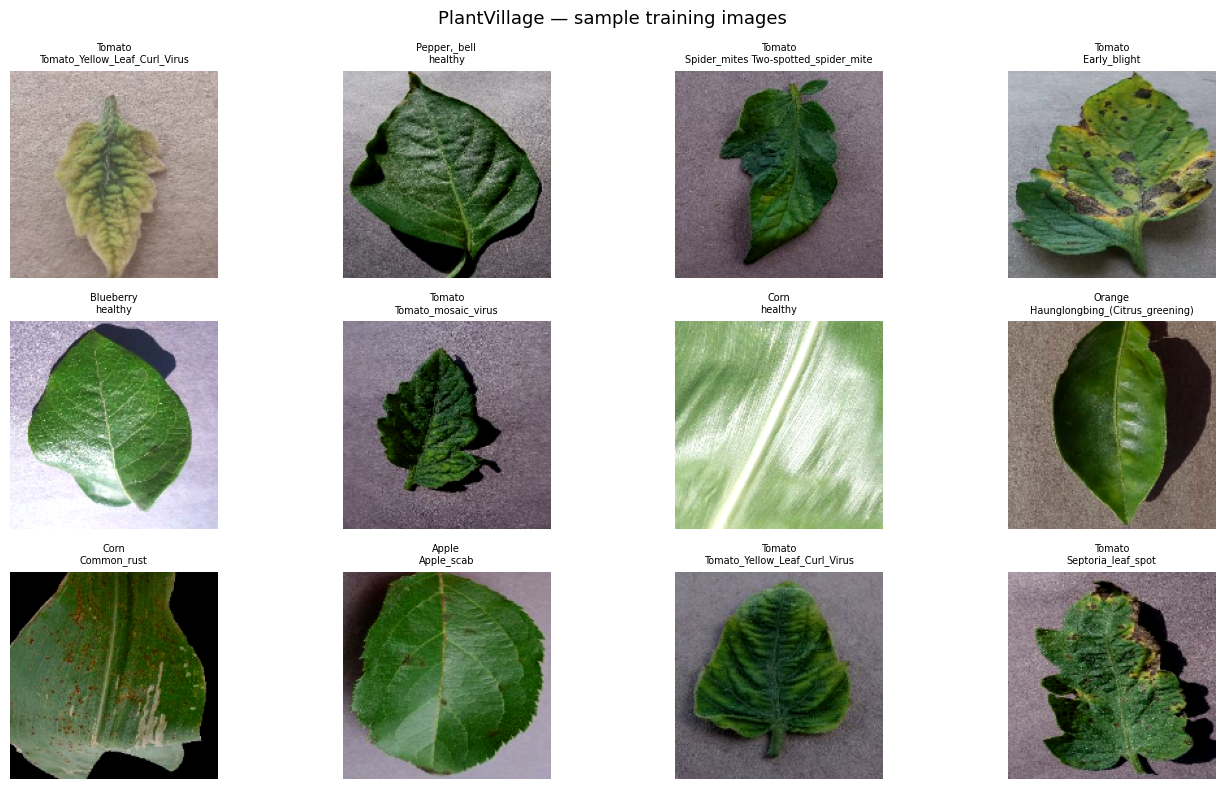

In [ ]:
# ── Visualize sample images ────────────────────────────────────────────────────
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))
sample_batch = next(iter(train_dataset.take(1)))
images, labels = sample_batch

for i in range(12):
    plt.subplot(3, 4, i+1)
    plt.imshow(images[i].numpy())
    plt.title(CLASS_NAMES[labels[i].numpy()].replace('___', '\n'),
              fontsize=7)
    plt.axis('off')

plt.suptitle('PlantVillage — sample training images', fontsize=13)
plt.tight_layout()
plt.show()

In [7]:
 # ── Build model (same MobileNetV2 as before) ───────────────────────────────────
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, callbacks
import tensorflow as tf

base = MobileNetV2(weights='imagenet', include_top=False,
                   input_shape=(*IMG_SIZE, 3))
base.trainable = False

inputs  = tf.keras.Input(shape=(*IMG_SIZE, 3))
x       = base(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

# ── Phase 1: train head ────────────────────────────────────────────────────────
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',   # use sparse because tfds gives integer labels
    metrics=['accuracy']
)

cb = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=4,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                                patience=2, verbose=1),
    callbacks.ModelCheckpoint('/content/best_model.keras',
                              save_best_only=True, monitor='val_accuracy')
]

print("Phase 1: training head only...")
hist1 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=cb
)

# ── Phase 2: fine-tune top 30 layers ──────────────────────────────────────────
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nPhase 2: fine-tuning...")
hist2 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,
    callbacks=cb
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Phase 1: training head only...
Epoch 1/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 1082s 2s/step - accuracy: 0.8360 - loss: 0.5575 - val_accuracy: 0.9283 - val_loss: 0.2128 - learning_rate: 0.0010
Epoch 2/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 1050s 2s/step - accuracy: 0.9063 - loss: 0.2867 - val_accuracy: 0.9400 - val_loss: 0.1771 - learning_rate: 0.0010
Epoch 3/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 1091s 2s/step - accuracy: 0.9234 - loss: 0.2337 - val_accuracy: 0.9444 - val_loss: 0.1653 - learning_rate: 0.0010
Epoch 4/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 1011s 2s/step - accuracy: 0.9279 - loss: 0.2174 - val_accuracy: 0.9488 - val_loss: 0.1526 - learning_rate: 0.0010
Epoch 5/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 1036s 2s/step - accuracy: 0.9337 - loss: 0.2000 - val_accuracy: 0.9518 - val_loss: 0.1419 - learning_rate: 0.0010
Epoch 6/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 992s 2s/step - accuracy: 0.9368 - loss: 0.1869 - val_accuracy: 0.9524 - val_loss: 0.1460 - learning_rate: 0.00

In [8]:
# ── Evaluate on test set ───────────────────────────────────────────────────────
test_loss, test_acc = model.evaluate(test_dataset, verbose=1)
print(f"\nTest Accuracy : {test_acc*100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")

128/128 ━━━━━━━━━━━━━━━━━━━━ 168s 1s/step - accuracy: 0.9446 - loss: 0.2010

Test Accuracy : 94.46%
Test Loss     : 0.2010
